# 🤖 MongoDB RAG Agent
### Agente conversacional con memoria y búsqueda semántica sobre documentación de MongoDB

---

**Arquitectura:**
```
Usuario → LLM (qwen2.5:14b) → Herramientas RAG → MongoDB Atlas → Respuesta
                    ↑                                    |
                    └──────── Memoria (MongoDB) ─────────┘
```

**Secciones:**
1. 📦 Setup y configuración *(ejecutar siempre al iniciar)*
2. 🗄️ Carga de datos a MongoDB *(ejecutar solo una vez — se salta automáticamente si ya hay datos)*
3. 🧠 Definición del agente y herramientas
4. 💬 Chat interactivo
5. 🔍 Diagnóstico y exploración *(opcional)*

---
## 📦 Sección 1 — Setup y configuración

Ejecuta esta sección completa siempre al iniciar el notebook.

In [1]:
import os
import subprocess
import sys

def setup_ssl():
    """
    Configura certificados SSL corporativos automáticamente.
    - macOS:   exporta desde el Keychain del sistema
    - Windows: exporta desde el Certificate Store de Windows
    - Linux:   usa /etc/ssl/certs del sistema
    """
    import certifi
    import tempfile

    certifi_bundle = certifi.where()
    with open(certifi_bundle, 'r') as f:
        bundle_content = f.read()

    if sys.platform == 'darwin':
        system_pem = os.path.expanduser('~/Desktop/system-certs.pem')

        if not os.path.exists(system_pem):
            print('📦 Exportando certificados del sistema macOS...')
            subprocess.run(['security', 'export', '-t', 'certs', '-f', 'pemseq',
                '-k', '/Library/Keychains/System.keychain', '-o', system_pem],
                check=True, capture_output=True)
            login_tmp = tempfile.mktemp(suffix='.pem')
            subprocess.run(['security', 'export', '-t', 'certs', '-f', 'pemseq',
                '-k', os.path.expanduser('~/Library/Keychains/login.keychain-db'),
                '-o', login_tmp], check=True, capture_output=True)
            with open(system_pem, 'a') as f_out:
                with open(login_tmp, 'r') as f_in:
                    f_out.write(f_in.read())
            os.remove(login_tmp)
            print(f'✅ Certificados exportados a {system_pem}')

        kasp = subprocess.run(['security', 'find-certificate', '-c', 'Kaspersky', '-a', '-p'],
            capture_output=True, text=True)
        kasp_cert = kasp.stdout.strip()

        with open(system_pem, 'r') as f:
            system_content = f.read()

        if kasp_cert and kasp_cert[:64] not in bundle_content:
            print('🔐 Agregando certificados corporativos a certifi...')
            with open(certifi_bundle, 'a') as f:
                f.write('\n' + system_content)
            print('✅ Certificados agregados al bundle de certifi')
        else:
            print('✅ Certificados corporativos ya presentes en certifi')

        os.environ['SSL_CERT_FILE']      = system_pem
        os.environ['REQUESTS_CA_BUNDLE'] = system_pem
        os.environ['CURL_CA_BUNDLE']     = system_pem
        print('✅ Variables de entorno SSL configuradas')

    elif sys.platform == 'win32':
        import ssl, base64
        print('📦 Leyendo certificados del Certificate Store de Windows...')
        new_certs = []
        for store_name in ('ROOT', 'CA', 'MY'):
            try:
                for cert_data, encoding, trust in ssl.enum_certificates(store_name):
                    if encoding == 'x509_asn':
                        pem = ('-----BEGIN CERTIFICATE-----\n'
                               + base64.b64encode(cert_data).decode('ascii')
                               + '\n-----END CERTIFICATE-----\n')
                        cert_id = base64.b64encode(cert_data).decode('ascii')[:64]
                        if cert_id not in bundle_content:
                            new_certs.append(pem)
            except Exception:
                continue
        if new_certs:
            print(f'🔐 Agregando {len(new_certs)} certificados nuevos a certifi...')
            with open(certifi_bundle, 'a') as f:
                f.write('\n' + '\n'.join(new_certs))
            print('✅ Certificados del sistema agregados al bundle de certifi')
        else:
            print('✅ Certificados del sistema ya presentes en certifi')
        os.environ['SSL_CERT_FILE']      = certifi_bundle
        os.environ['REQUESTS_CA_BUNDLE'] = certifi_bundle
        os.environ['CURL_CA_BUNDLE']     = certifi_bundle
        print('✅ Variables de entorno SSL configuradas')

    else:
        print('ℹ️  Linux detectado — usando certificados del sistema directamente.')
        system_ca = '/etc/ssl/certs/ca-certificates.crt'
        if os.path.exists(system_ca):
            os.environ['SSL_CERT_FILE']      = system_ca
            os.environ['REQUESTS_CA_BUNDLE'] = system_ca
            print('✅ Usando /etc/ssl/certs/ca-certificates.crt')

setup_ssl()

✅ Certificados corporativos ya presentes en certifi
✅ Variables de entorno SSL configuradas


In [2]:
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ipywidgets', '-q'])
print('✅ Dependencias listas')

✅ Dependencias listas


In [3]:
try:
    import key_param
    MONGODB_URI    = key_param.mongodb_uri
    VOYAGE_API_KEY = key_param.voyage_api_key
    print('✅ Credenciales cargadas desde key_param.py')
except ImportError:
    MONGODB_URI    = 'tu_mongodb_uri_aqui'
    VOYAGE_API_KEY = 'tu_voyage_api_key_aqui'
    print('⚠️  Usando credenciales definidas manualmente')

DB_NAME         = 'ai_agents'
FULL_COLLECTION = 'full_docs'
VS_COLLECTION   = 'chunked_docs'
VS_INDEX_NAME   = 'vector_index'
DATA_ALREADY_LOADED = False

print(f'📡 Conectando a: {MONGODB_URI[:40]}...')

✅ Credenciales cargadas desde key_param.py
📡 Conectando a: mongodb+srv://zpino_db_user:6dZjlDMcR3Nf...


In [4]:
from pymongo import MongoClient
import voyageai
import certifi

def get_mongodb_client():
    """Retorna un cliente MongoDB con TLS configurado."""
    return MongoClient(MONGODB_URI, tlsCAFile=certifi.where())

try:
    client = get_mongodb_client()
    client.admin.command('ping')
    print('✅ Conexión a MongoDB Atlas exitosa')
except Exception as e:
    print(f'❌ Error de conexión: {e}')

✅ Conexión a MongoDB Atlas exitosa


---
## 🗄️ Sección 2 — Carga de datos a MongoDB

> ⚠️ **Ejecutar solo una vez.** La primera celda es el punto de control: verifica si ya existen datos
> en MongoDB Atlas y setea `DATA_ALREADY_LOADED`. Las celdas siguientes se saltan automáticamente
> si los datos ya están cargados.

In [5]:
# ─── PUNTO DE CONTROL ─────────────────────────────────────────────────────────
client = get_mongodb_client()
db = client[DB_NAME]

full_count = db[FULL_COLLECTION].count_documents({})
vs_count   = db[VS_COLLECTION].count_documents({})

print(f"📄 Documentos en '{FULL_COLLECTION}': {full_count}")
print(f"🔢 Documentos en '{VS_COLLECTION}':  {vs_count}")

if full_count > 0 and vs_count > 0:
    DATA_ALREADY_LOADED = True
    print('\n✅ Datos ya cargados — las celdas de carga se saltarán automáticamente.')
    print('   Puedes continuar directamente a la Sección 3.')
else:
    DATA_ALREADY_LOADED = False
    print('\n⚠️  No hay datos. Las celdas siguientes procederán con la carga.')

📄 Documentos en 'full_docs': 60
🔢 Documentos en 'chunked_docs':  113

✅ Datos ya cargados — las celdas de carga se saltarán automáticamente.
   Puedes continuar directamente a la Sección 3.


In [6]:
if DATA_ALREADY_LOADED:
    print('⏭️  Datos ya cargados — celda omitida.')
else:
    from datasets import load_dataset
    print('⬇️  Descargando datasets desde Hugging Face...')
    docs         = load_dataset('MongoDB/mongodb-docs',          download_mode='reuse_cache_if_exists')
    chunked_docs = load_dataset('MongoDB/mongodb-docs-embedded', download_mode='reuse_cache_if_exists')
    print(f"✅ Datasets descargados — docs: {len(docs['train'])}, chunks: {len(chunked_docs['train'])}")

⏭️  Datos ya cargados — celda omitida.


In [7]:
if DATA_ALREADY_LOADED:
    print('⏭️  Datos ya cargados — celda omitida.')
else:
    client = get_mongodb_client()
    full_collection = client[DB_NAME][FULL_COLLECTION]
    print(f"📝 Insertando {len(docs['train'])} documentos completos...")
    for i, doc in enumerate(docs['train']):
        full_collection.insert_one(doc)
        if (i + 1) % 5 == 0:
            print(f"   {i+1}/{len(docs['train'])} insertados")
    print(f"✅ {len(docs['train'])} documentos completos insertados en '{FULL_COLLECTION}'")

⏭️  Datos ya cargados — celda omitida.


In [8]:
if DATA_ALREADY_LOADED:
    print('⏭️  Datos ya cargados — celda omitida.')
else:
    import time
    client = get_mongodb_client()
    vs_collection = client[DB_NAME][VS_COLLECTION]
    vo = voyageai.Client(api_key=VOYAGE_API_KEY)
    total = len(chunked_docs['train'])
    print(f'🔢 Generando embeddings para {total} chunks...')
    print('   (Esto puede tomar varios minutos)\n')
    for i, chunked_doc in enumerate(chunked_docs['train']):
        try:
            embedding = vo.embed(chunked_doc['body'], model='voyage-3-lite',
                input_type='document').embeddings[0]
        except Exception as e:
            if 'RateLimitError' in type(e).__name__ or 'rate' in str(e).lower():
                print(f'   ⏳ Rate limit — esperando 60s... (chunk {i+1}/{total})')
                time.sleep(60)
                embedding = vo.embed(chunked_doc['body'], model='voyage-3-lite',
                    input_type='document').embeddings[0]
            else:
                raise
        chunked_doc['embedding'] = embedding
        vs_collection.insert_one(chunked_doc)
        if (i + 1) % 10 == 0:
            print(f'   ✅ {i+1}/{total} chunks procesados')
    print(f'\n✅ {total} chunks con embeddings insertados en "{VS_COLLECTION}"')

⏭️  Datos ya cargados — celda omitida.


In [9]:
if DATA_ALREADY_LOADED:
    print('⏭️  Datos ya cargados — celda omitida.')
else:
    client = get_mongodb_client()
    vs_collection = client[DB_NAME][VS_COLLECTION]
    model = {
        'name': VS_INDEX_NAME, 'type': 'vectorSearch',
        'definition': {'fields': [{
            'type': 'vector', 'path': 'embedding',
            'numDimensions': 512, 'similarity': 'cosine'
        }]}
    }
    try:
        vs_collection.create_search_index(model=model)
        print('✅ Índice vectorial creado. Espera 1-2 minutos para que esté activo en Atlas.')
    except Exception as e:
        if 'already exists' in str(e).lower():
            print('ℹ️  El índice vectorial ya existe.')
        else:
            raise

⏭️  Datos ya cargados — celda omitida.


---
## 🧠 Sección 3 — Definición del agente RAG

Ejecuta estas celdas para inicializar el agente. Solo necesitas hacerlo una vez por sesión.

In [10]:
from typing import List, Annotated
from typing_extensions import TypedDict
from langchain.agents import tool
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import ToolMessage
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.mongodb import MongoDBSaver

print('✅ Imports del agente cargados')

✅ Imports del agente cargados


/Users/zpino/dev/mongodb/github/mdb-university/AI-Agents-with-MongoDB/01-Building-AI-Agents-with-MongoDB/.venv/lib/python3.12/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [11]:
def get_collections():
    client = get_mongodb_client()
    db = client[DB_NAME]
    return client, db[VS_COLLECTION], db[FULL_COLLECTION]

def generate_embedding(text: str) -> List[float]:
    vo = voyageai.Client(api_key=VOYAGE_API_KEY)
    return vo.embed(text, model='voyage-3-lite', input_type='query').embeddings[0]

print('✅ Funciones de acceso definidas')

✅ Funciones de acceso definidas


In [12]:
@tool
def get_information_for_question_answering(user_query: str) -> str:
    """
    Recupera documentos relevantes para responder una pregunta del usuario
    usando búsqueda vectorial semántica.

    Args:
        user_query: La pregunta del usuario.

    Returns:
        Los documentos recuperados como string.
    """
    query_embedding = generate_embedding(user_query)
    _, vs_collection, _ = get_collections()
    pipeline = [
        {'$vectorSearch': {'index': VS_INDEX_NAME, 'path': 'embedding',
            'queryVector': query_embedding, 'numCandidates': 150, 'limit': 5}},
        {'$project': {'_id': 0, 'body': 1, 'score': {'$meta': 'vectorSearchScore'}}}
    ]
    results = vs_collection.aggregate(pipeline)
    context = '\n\n'.join([doc.get('body', '') for doc in results])
    return context if context else 'No se encontraron documentos relevantes.'


@tool
def get_page_content_for_summarization(user_query: str) -> str:
    """
    Recupera el contenido completo de una página de documentación para resumirla.

    Args:
        user_query: El título exacto de la página de documentación.

    Returns:
        El contenido de la página como string.
    """
    _, _, full_collection = get_collections()
    document = full_collection.find_one({'title': user_query}, {'_id': 0, 'body': 1})
    return document['body'] if document else 'Documento no encontrado.'


tools = [get_information_for_question_answering, get_page_content_for_summarization]
tools_by_name = {t.name: t for t in tools}

print('✅ Herramientas definidas:')
for t in tools:
    print(f'   🔧 {t.name}')

✅ Herramientas definidas:
   🔧 get_information_for_question_answering
   🔧 get_page_content_for_summarization


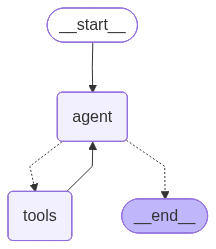

✅ Agente RAG inicializado y listo


In [13]:
class GraphState(TypedDict):
    messages: Annotated[list, add_messages]

def agent_node(state: GraphState, llm_with_tools) -> GraphState:
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

def tool_node(state: GraphState) -> GraphState:
    result = []
    for tool_call in state['messages'][-1].tool_calls:
        tool = tools_by_name[tool_call['name']]
        observation = tool.invoke(tool_call['args'])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call['id']))
    return {'messages': result}

def route_tools(state: GraphState):
    last = state['messages'][-1]
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return 'tools'
    return END

def build_agent(mongodb_client):
    llm = ChatOllama(temperature=0, model='qwen2.5:14b')
    prompt = ChatPromptTemplate.from_messages([
        ('system',
         'Always respond in the same language the user uses. '
         'You are a helpful AI assistant specialized in MongoDB documentation. '
         'Use the provided tools to answer questions about MongoDB. '
         'Think step-by-step and use tools to get the information needed. '
         'Do not re-run tools unless necessary. '
         'If you cannot find enough information, reply with I DONT KNOW. '
         'Available tools: {tool_names}.'),
        MessagesPlaceholder(variable_name='messages'),
    ])
    prompt = prompt.partial(tool_names=', '.join([t.name for t in tools]))
    llm_with_tools = prompt | llm.bind_tools(tools)

    graph = StateGraph(GraphState)
    graph.add_node('agent', lambda state: agent_node(state, llm_with_tools))
    graph.add_node('tools', tool_node)
    graph.add_edge(START, 'agent')
    graph.add_edge('tools', 'agent')
    graph.add_conditional_edges('agent', route_tools, {'tools': 'tools', END: END})

    checkpointer = MongoDBSaver(mongodb_client)
    app_graph = graph.compile(checkpointer=checkpointer)

    from IPython.display import Image, display
    display(Image(app_graph.get_graph().draw_mermaid_png()))

    return app_graph

mongodb_client = get_mongodb_client()
app = build_agent(mongodb_client)
print('✅ Agente RAG inicializado y listo')

---
## 💬 Sección 4 — Chat interactivo

Cada conversación tiene un `thread_id`. El agente recuerda el historial dentro del mismo thread.

- Mantén el mismo `THREAD_ID` para continuar una conversación existente.
- Presiona **"Nueva sesión"** para iniciar una conversación desde cero.

In [14]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import uuid

# ─── VARIABLES GLOBALES ───────────────────────────────────────────────────────
THREAD_ID    = 'session-1'
chat_history = []
_processing  = False

# Cerrar widgets previos si existen en el namespace
for _var_name in ['chat_output', 'text_input', 'send_button', 
                  'clear_button', 'status_label', 'input_row', '_chat_html']:
    try:
        globals()[_var_name].close()
    except (NameError, Exception):
        pass

def ask_agent(question: str, thread_id: str) -> str:
    config    = {'configurable': {'thread_id': thread_id}}
    input_msg = {'messages': [('user', question)]}
    final_answer = ''
    for output in app.stream(input_msg, config):
        for key, value in output.items():
            if key == 'agent' and value['messages']:
                last = value['messages'][-1]
                if hasattr(last, 'content') and last.content:
                    final_answer = last.content
    return final_answer

def render_chat():
    css = """
    <style>
        .chat-container { font-family: 'Segoe UI', sans-serif; max-width: 800px;
            padding: 12px; background: #1e1e2e; border-radius: 12px; margin-bottom: 12px; }
        .chat-header { color: #cdd6f4; font-size: 13px; margin-bottom: 12px;
            padding-bottom: 8px; border-bottom: 1px solid #313244; }
        .msg-user { background: #313244; color: #cdd6f4; border-radius: 12px 12px 4px 12px;
            padding: 10px 14px; margin: 6px 0 6px 80px; font-size: 14px; line-height: 1.5; }
        .msg-agent { background: #181825; color: #a6e3a1; border-radius: 12px 12px 12px 4px;
            padding: 10px 14px; margin: 6px 80px 6px 0; font-size: 14px; line-height: 1.6;
            border-left: 3px solid #a6e3a1; }
        .msg-label { font-size: 11px; font-weight: 600; margin-bottom: 4px; opacity: 0.6; }
        .label-user  { color: #89b4fa; text-align: right; }
        .label-agent { color: #a6e3a1; }
        .empty-state { color: #585b70; text-align: center; padding: 24px; font-size: 13px; }
    </style>
    """
    header = f"<div class='chat-container'><div class='chat-header'>🤖 MongoDB RAG Agent &nbsp;|&nbsp; Thread: <code style='color:#89b4fa'>{THREAD_ID}</code></div>"
    if not chat_history:
        body = "<div class='empty-state'>Aún no hay mensajes. ¡Haz una pregunta!</div>"
    else:
        body = ''
        for role, text in chat_history:
            text_safe = text.replace('\n', '<br>')
            if role == 'user':
                body += f"<div class='msg-label label-user'>Tú</div><div class='msg-user'>{text_safe}</div>"
            else:
                body += f"<div class='msg-label label-agent'>🤖 Agente</div><div class='msg-agent'>{text_safe}</div>"
    return css + header + body + '</div>'


# ─── CREAR WIDGETS ────────────────────────────────────────────────────────────
# USAR HTML WIDGET en lugar de Output widget para evitar duplicación
_chat_html = widgets.HTML(value=render_chat())

text_input = widgets.Text(
    placeholder='Escribe tu pregunta sobre MongoDB...',
    continuous_update=False,
    layout=widgets.Layout(width='75%')
)
send_button = widgets.Button(
    description='Enviar',
    button_style='primary',
    layout=widgets.Layout(width='12%')
)
clear_button = widgets.Button(
    description='Nueva sesión',
    button_style='warning',
    layout=widgets.Layout(width='13%')
)
status_label = widgets.Label(value='')
input_row = widgets.HBox([text_input, send_button, clear_button])

# ─── HANDLERS ─────────────────────────────────────────────────────────────────
def refresh_display():
    """Actualiza el widget HTML directamente, sin display() ni clear_output()"""
    _chat_html.value = render_chat()

def on_send(b):
    global THREAD_ID, _processing
    if _processing:
        return
    question = text_input.value.strip()
    if not question:
        return

    _processing = True
    text_input.unobserve(on_enter, names='value')
    text_input.value = ''
    text_input.disabled = True
    send_button.disabled = True
    status_label.value = '⏳ El agente está pensando...'

    chat_history.append(('user', question))
    refresh_display()  # ← Actualiza el HTML directamente

    try:
        answer = ask_agent(question, THREAD_ID)
        chat_history.append(('agent', answer))
    except Exception as e:
        chat_history.append(('agent', f'❌ Error: {str(e)}'))

    status_label.value = ''
    text_input.disabled = False
    _processing = False
    text_input.observe(on_enter, names='value')
    send_button.disabled = False
    refresh_display()  # ← Actualiza el HTML directamente

def on_clear(b):
    global THREAD_ID, chat_history
    THREAD_ID = f'session-{uuid.uuid4().hex[:6]}'
    chat_history = []
    refresh_display()
    status_label.value = f'🆕 Nueva sesión: {THREAD_ID}'

def on_enter(change):
    if change['new'].strip() and not _processing:
        on_send(None)

# ─── CONECTAR EVENTOS ─────────────────────────────────────────────────────────
text_input.observe(on_enter, names='value')
send_button.on_click(on_send)
clear_button.on_click(on_clear)

# ─── MOSTRAR UNA SOLA VEZ ─────────────────────────────────────────────────────
display(_chat_html, input_row, status_label)
print("💬 Chat listo. Escribe tu pregunta y presiona Enter o 'Enviar'.")

HTML(value="\n    <style>\n        .chat-container { font-family: 'Segoe UI', sans-serif; max-width: 800px;\n …

Label(value='')

💬 Chat listo. Escribe tu pregunta y presiona Enter o 'Enviar'.


---
## 🔍 Sección 5 — Diagnóstico y exploración *(opcional)*

Celdas útiles para inspeccionar el estado del sistema. No forman parte del flujo principal.

In [ ]:
# ─── Estado de las colecciones en MongoDB Atlas ───────────────────────────────
client = get_mongodb_client()
db = client[DB_NAME]
print('📊 Estado de MongoDB Atlas:')
print(f"   full_docs:    {db[FULL_COLLECTION].count_documents({}):>5} documentos")
print(f"   chunked_docs: {db[VS_COLLECTION].count_documents({}):>5} chunks con embeddings")
sample = db[FULL_COLLECTION].find_one({}, {'_id': 0, 'title': 1, 'body': 1})
if sample:
    print(f"\n📄 Ejemplo de documento:")
    print(f"   Título: {sample.get('title', 'N/A')}")
    print(f"   Body:   {str(sample.get('body', ''))[:150]}...")

In [ ]:
# ─── Probar búsqueda vectorial directamente ───────────────────────────────────
test_query = 'How to create indexes in MongoDB?'
print(f"🔍 Probando búsqueda vectorial para: '{test_query}'\n")
result = get_information_for_question_answering.invoke({'user_query': test_query})
print(result[:500] + '...' if len(result) > 500 else result)

In [ ]:
# ─── Ver historial del chat de la sesión actual ───────────────────────────────
print(f"📜 Historial de sesión '{THREAD_ID}':")
for i, (role, msg) in enumerate(chat_history):
    icon = '👤' if role == 'user' else '🤖'
    print(f"\n[{i+1}] {icon} {role.upper()}:")
    print(f"    {msg[:200]}{'...' if len(msg) > 200 else ''}")

In [ ]:
# ─── Diagnóstico SSL y conectividad ──────────────────────────────────────────
system_pem = os.path.expanduser('~/Desktop/system-certs.pem')
print(f'1. system-certs.pem existe: {os.path.exists(system_pem)}')

if sys.platform == 'darwin':
    kasp = subprocess.run(['security', 'find-certificate', '-c', 'Kaspersky', '-a', '-p'],
        capture_output=True, text=True)
    kasp_cert = kasp.stdout.strip()
    print(f"2. Cert Kaspersky en Keychain: {'Sí' if kasp_cert else 'No'}")
    if os.path.exists(system_pem):
        with open(system_pem) as f:
            sc = f.read()
        print(f"3. Cert Kaspersky en system-certs.pem: {'Sí' if kasp_cert[:64] in sc else 'NO ❌'}")
    with open(certifi.where()) as f:
        cb = f.read()
    print(f"4. Cert Kaspersky en certifi bundle: {'Sí' if kasp_cert[:64] in cb else 'NO ❌'}")

print(f"5. SSL_CERT_FILE: {os.environ.get('SSL_CERT_FILE', 'NO DEFINIDA ❌')}")

print('\n6. Probando conexión a MongoDB Atlas...')
try:
    c = get_mongodb_client()
    c.admin.command('ping')
    print('   ✅ Conexión OK')
except Exception as e:
    print(f'   ❌ {str(e)[:100]}')

print('\n7. IP pública actual:')
r = subprocess.run(['curl', '-s', 'https://api.ipify.org'], capture_output=True, text=True)
print(f'   {r.stdout}')